**Data layout (TIFF supported):**
```
./Data/
  Train/
    Normal/      *.tif, *.tiff, *.png, *.jpg
    Abnormal/    *.tif, *.tiff, *.png, *.jpg
  Validation/
    Normal/
    Abnormal/
  Test/
    Normal/      (used for pretrained-weight evaluation)
    Abnormal/
```
Pretrained weights are auto-downloaded from Google Drive into `./checkpoints/<ckpt_name>` right before evaluation.

> **Colab/GitHub-ready:** This notebook uses relative paths (`./data`, `./checkpoints`) so it runs smoothly when opened from GitHub in Colab.  
> **Training:** runs for **5 epochs** and saves to `./checkpoints/best_train.pth`.  
> **Evaluation:** uses your pretrained file `./checkpoints/epoch=75-val_loss=0.69-val_acc=0.77.ckpt`.

# 🧪 Sperm Classification (Normal vs Abnormal) — DenseNet-169 (Colab Notebook)

**Goal:** quick, accurate *trial* training run (10 epochs) using **DenseNet‑169**. This notebook keeps key hyperparameters consistent with your setup: **image size 800×800** and normalization `mean=0.2636`, `std=0.1562`. It also provides a simple evaluation section to load **your pretrained weights** and run on test images.

> Tip: The setup cell below places the notebook in the `classification/` directory. If you store data or weights in Google Drive, use the optional Drive mount cell after it.

## 1) Get the workshop files

Run this cell first. In Google Colab it clones the workshop repository, then changes into its `classification/` directory so that `./Data` points to `classification/Data`. When the notebook is run locally from that directory, no clone is needed.

In [1]:
from pathlib import Path
import os
import subprocess

REPO_URL = 'https://github.com/KikuchiJun1/MicroTas-2026-Workshop-10.git'
REPO_DIR_NAME = 'MicroTas-2026-Workshop-10'
cwd = Path.cwd()

# Support both a local launch from classification/ and a fresh Colab runtime.
if (cwd / 'Data').is_dir():
    classification_dir = cwd
elif (cwd / 'classification' / 'Data').is_dir():
    classification_dir = cwd / 'classification'
else:
    repo_dir = cwd / REPO_DIR_NAME
    if not repo_dir.exists():
        print('Cloning repository...')
        subprocess.run(['git', 'clone', REPO_URL, REPO_DIR_NAME], check=True)
    classification_dir = repo_dir / 'classification'

if not (classification_dir / 'Data').is_dir():
    raise FileNotFoundError(f'Could not find classification/Data in {classification_dir}')

os.chdir(classification_dir)
print(f'Working directory: {Path.cwd()}')
print('Dataset directory:', Path('Data').resolve())


Cloning repository...
Working directory: /content/MicroTas-2026-Workshop-10/classification
Dataset directory: /content/MicroTas-2026-Workshop-10/classification/Data


## 2) Runtime & Drive (optional)
If your images/checkpoints live in Drive, mount it first.

In [2]:
# (Optional) Mount Google Drive if needed
# from google.colab import drive
# drive.mount('/content/drive')
#
# After mounting, you can refer to files like:
# data_dir = '/content/drive/MyDrive/your_dataset_root'
# weights_path = '/content/drive/MyDrive/weights/densenet169_sperm.pth'


## 3) Setup
Colab usually has recent PyTorch/torchvision. If you need specific versions, uncomment the cell below.

In [3]:
# If you need to pin specific versions, uncomment and set the versions you prefer
# !pip install --quiet torch torchvision torchmetrics==1.4.0


## 4) Configuration
Set your dataset paths, batch size, and training hyperparameters. We use **800×800** images and the grayscale normalization stats you provided. We convert grayscale to **3 channels** inside the transform (to feed DenseNet).

In [4]:
# ===== Imports =====
import os
from dataclasses import dataclass

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms  # ImageFolder + transforms

# ===== Config =====
@dataclass
class CFG:
    # Paths
    data_dir: str = "./Data"            # has Train, Validation, Test

    # Training
    epochs: int = 5
    batch_size: int = 1
    num_workers: int = 2
    lr: float = 1e-4
    weight_decay: float = 0.0
    seed: int = 42

    # Image/Transforms
    img_size: int = 800
    mean: float = 0.2636
    std: float = 0.1562

    # Checkpoints
    save_dir: str = "./checkpoints"
    ckpt_name: str = "epoch=75-val_loss=0.69-val_acc=0.77.ckpt"  # PRETRAINED (used for eval)
    train_ckpt_name: str = "best_train.pth"                      # saved during 5-epoch training

cfg = CFG()
print(cfg)

# ===== Transforms (TIFF supported via PIL under the hood) =====
IM_SIZE = cfg.img_size
MEAN = [cfg.mean, cfg.mean, cfg.mean]
STD  = [cfg.std,  cfg.std,  cfg.std]

# For DenseNet we provide 3-channel input; your data are grayscale TIFFs, so convert to 3 channels first.
train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ===== Datasets & Loaders =====
# Expect ImageFolder layout with /Train, /Validation, /Test under cfg.data_dir
train_dir = os.path.join(cfg.data_dir, "Train")
val_dir   = os.path.join(cfg.data_dir, "Validation")
test_dir  = os.path.join(cfg.data_dir, "Test")

# ImageFolder will read subfolders "Normal" and "Abnormal"
train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir,   transform=val_tfms)
test_ds  = datasets.ImageFolder(test_dir,  transform=val_tfms)

class_names = train_ds.classes
print(f"Classes: {class_names}")

pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)


CFG(data_dir='./Data', epochs=5, batch_size=1, num_workers=2, lr=0.0001, weight_decay=0.0, seed=42, img_size=800, mean=0.2636, std=0.1562, save_dir='./checkpoints', ckpt_name='epoch=75-val_loss=0.69-val_acc=0.77.ckpt', train_ckpt_name='best_train.pth')
Classes: ['Abnormal', 'Normal']


## 5) Imports & Reproducibility
from PIL import Image


In [5]:
import os, random, math, time
from pathlib import Path

import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image  # <-- keep this on its own line, with no '\n' before it

# Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(cfg.seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

## 6) Datasets & Dataloaders
We keep your normalization and effective grayscale handling. We convert grayscale to 3 channels so DenseNet‑169 can ingest it, but the **statistics remain the same** (we just repeat the single channel values across RGB).

In [6]:
# Transforms — training includes flips; validation only resize+normalize.
# Convert grayscale TIFFs to 3 channels (RGB) so DenseNet works, but keep grayscale stats.

IM_SIZE = cfg.img_size
MEAN = [cfg.mean, cfg.mean, cfg.mean]
STD  = [cfg.std,  cfg.std,  cfg.std]

train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IM_SIZE, IM_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Expect ImageFolder layout with /Train and /Validation under cfg.data_dir
train_dir = os.path.join(cfg.data_dir, "Train")
val_dir   = os.path.join(cfg.data_dir, "Validation")

train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir,   transform=val_tfms)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Classes: {class_names} -> num_classes={num_classes}")

pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)

len(train_ds), len(val_ds)


Classes: ['Abnormal', 'Normal'] -> num_classes=2


(20, 8)

## 7) Model — DenseNet‑169 (pretrained)
We replace the classifier with a 2‑unit linear layer for binary classification. Loss: `CrossEntropyLoss`. Optimizer: `Adam` (lr=1e-4 by default).

In [7]:
# Build DenseNet-169
dnet = models.densenet169(weights=models.DenseNet169_Weights.DEFAULT)

# Replace classifier for our task
in_features = dnet.classifier.in_features
dnet.classifier = nn.Linear(in_features, 2)

dnet = dnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dnet.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 128MB/s]


## 8) Training Loop (5 epochs)
A minimal, well‑commented loop with val accuracy each epoch. Checkpoints are saved to `cfg.save_dir`.

In [8]:
from typing import Dict
import os, time
import torch

os.makedirs(cfg.save_dir, exist_ok=True)
best_val_acc = 0.0
history: Dict[str, list] = {"train_loss": [], "val_loss": [], "val_acc": []}

def run_epoch(model: torch.nn.Module, loader: torch.utils.data.DataLoader, train: bool) -> tuple[float, float]:
    epoch_loss = 0.0
    total = 0
    correct = 0

    if train:
        model.train()
        ctx = torch.enable_grad()
    else:
        model.eval()
        ctx = torch.inference_mode()

    with ctx:
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if train:
                optimizer.zero_grad()

            outputs = model(images)              # logits
            loss = criterion(outputs, labels)    # CE loss

            if train:
                loss.backward()
                optimizer.step()

            epoch_loss += loss.item() * images.size(0)

            # accuracy on the fly
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = epoch_loss / max(1, total)
    acc = correct / max(1, total)
    return avg_loss, acc

for epoch in range(1, cfg.epochs + 1):
    t0 = time.time()
    train_loss, _      = run_epoch(dnet, train_loader, train=True)
    val_loss, val_acc  = run_epoch(dnet, val_loader,  train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_path = os.path.join(cfg.save_dir, cfg.train_ckpt_name)
        torch.save(
            {
                "model_state": dnet.state_dict(),
                "class_names": class_names,
                "cfg": vars(cfg),
            },
            best_path,
        )

    t1 = time.time()
    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | "
        f"time: {t1 - t0:.1f}s"
    )

print(f"Best val_acc: {best_val_acc:.4f} | Saved to: {os.path.join(cfg.save_dir, cfg.train_ckpt_name)}")


Epoch 01/5 | train_loss: 0.7509 | val_loss: 0.7171 | val_acc: 0.5000 | time: 6.3s
Epoch 02/5 | train_loss: 0.7337 | val_loss: 0.2448 | val_acc: 1.0000 | time: 4.0s
Epoch 03/5 | train_loss: 0.7422 | val_loss: 0.4698 | val_acc: 1.0000 | time: 3.8s
Epoch 04/5 | train_loss: 0.7332 | val_loss: 0.5464 | val_acc: 0.5000 | time: 4.2s
Epoch 05/5 | train_loss: 0.7393 | val_loss: 0.5625 | val_acc: 0.5000 | time: 3.8s
Best val_acc: 1.0000 | Saved to: ./checkpoints/best_train.pth


## 9) Plot Training Curves

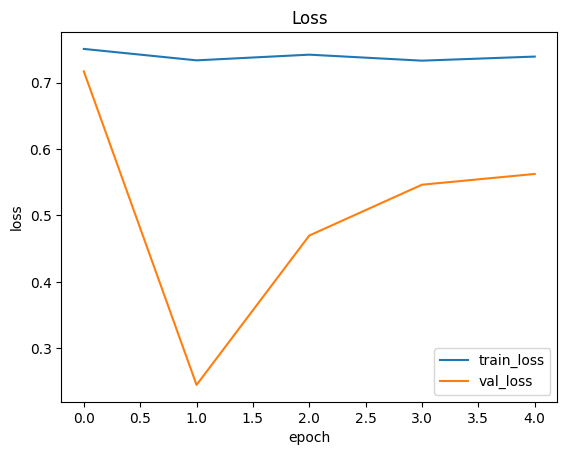

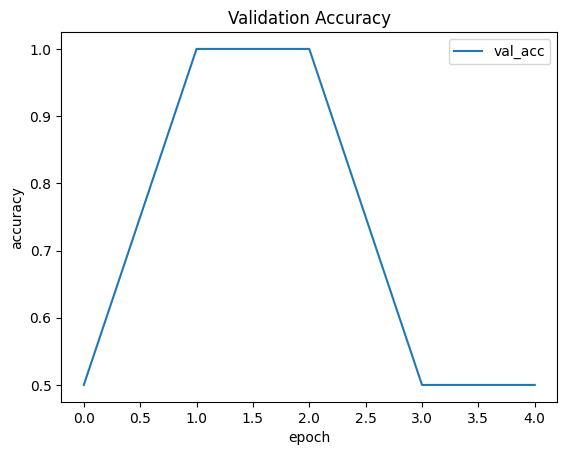

In [9]:
# Plot loss and val accuracy
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss")

plt.figure()
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("Validation Accuracy")

plt.show()

## 10) Evaluation — Load Pretrained Weights and Test
Point `weights_path` to your pretrained checkpoint (`.pth`) saved by this notebook **or your own weights**. We provide both **single‑image test** and **folder‑based batch test** with a confusion matrix.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

def _strip_prefix_if_present(state_dict, prefixes=("model.", "net.", "module.", "backbone.")):
    new_sd = {}
    for k, v in state_dict.items():
        new_key = k
        for p in prefixes:
            if new_key.startswith(p):
                new_key = new_key[len(p):]
        new_sd[new_key] = v
    return new_sd

def load_model_for_inference(weights_path: str, num_classes=2, class_names_override=None):
    model = models.densenet169(weights=models.DenseNet169_Weights.DEFAULT)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    ckpt = torch.load(weights_path, map_location="cpu")
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    elif isinstance(ckpt, dict) and "model_state" in ckpt:
        state_dict = ckpt["model_state"]
    else:
        state_dict = ckpt
    state_dict = _strip_prefix_if_present(state_dict)
    model.load_state_dict(state_dict, strict=False)
    model.eval().to(device)
    if isinstance(ckpt, dict):
        class_names = ckpt.get("class_names", class_names_override or ["Normal", "Abnormal"])
    else:
        class_names = class_names_override or ["Normal", "Abnormal"]
    return model, class_names

print("Inference loader ready.")

Inference loader ready.


### 10.a) Download and load pretrained weights

This cell is deliberately placed before any inference. On a fresh runtime, it downloads the checkpoint once; on later runs, it reuses the local copy.

In [11]:
import torch.nn.functional as F

# Download the pretrained checkpoint before attempting to load it.
# Requires the shared Google Drive file to be available to anyone with the link.
try:
    import gdown  # type: ignore
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "gdown"])
    import gdown  # type: ignore

os.makedirs(cfg.save_dir, exist_ok=True)
drive_file_id = "1mMh2Fs-dcsiRWKR5rXkVR0RP7Tg9MNAf"
weights_path = os.path.join(cfg.save_dir, cfg.ckpt_name)

if not os.path.exists(weights_path):
    url = f"https://drive.google.com/uc?id={drive_file_id}"
    print("Downloading pretrained weights to:", weights_path)
    gdown.download(url, weights_path, quiet=False)
else:
    print("Pretrained weights already present at:", weights_path)

# Allowlist the specific global causing the PyTorch 2.6+ UnpicklingError
torch.serialization.add_safe_globals([F.cross_entropy])

# Evaluation uses the pretrained checkpoint; it is never overwritten by training.
weights_path = os.path.join(cfg.save_dir, cfg.ckpt_name)
model_inf, class_names_inf = load_model_for_inference(weights_path)
print("Loaded inference model; classes:", class_names_inf)

Downloading...
From (original): https://drive.google.com/uc?id=1mMh2Fs-dcsiRWKR5rXkVR0RP7Tg9MNAf
From (redirected): https://drive.google.com/uc?id=1mMh2Fs-dcsiRWKR5rXkVR0RP7Tg9MNAf&confirm=t&uuid=0e3d566d-f3b1-44b4-bc1f-cc5765659f03
To: /content/MicroTas-2026-Workshop-10/classification/checkpoints/epoch=75-val_loss=0.69-val_acc=0.77.ckpt
100%|██████████| 256M/256M [00:02<00:00, 123MB/s]


Loaded inference model; classes: ['Normal', 'Abnormal']


### 10.b) Single‑image prediction

In [12]:
# Set an example image
# img_path = "/content/data/val/Normal/example_001.png"
# result = predict_single_image(img_path, model_inf, class_names_inf)
# print(result)

### 10.c) Batch evaluation on a folder (e.g., your validation set)

In [13]:
# data_root = "/content/data/val"
# cm, report, classes = evaluate_folder(data_root, model_inf, val_tfms)
# print("Classes:", classes)
# print("Classification report:\n", report)

# # Plot confusion matrix (no seaborn, simple matplotlib)
# import itertools
# plt.figure()
# plt.imshow(cm, interpolation='nearest')
# plt.title("Confusion Matrix")
# plt.colorbar()
# tick_marks = np.arange(len(classes))
# plt.xticks(tick_marks, classes, rotation=45)
# plt.yticks(tick_marks, classes)

# thresh = cm.max() / 2.
# for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
#     plt.text(j, i, format(cm[i, j], 'd'),
#              horizontalalignment="center",
#              color="white" if cm[i, j] > thresh else "black")

# plt.ylabel('True label')
# plt.xlabel('Predicted label')
# plt.tight_layout()
# plt.show()

## 11) Notes
- Image size kept at **800×800** to match your code.
- Normalization kept at **mean=0.2636**, **std=0.1562** (replicated across 3 channels under the hood).
- Random H/V flips used in training, none in validation — consistent with your approach.
- You can easily swap the dataset paths or use Drive.
- For a quick run, keep 10 epochs; adjust later as needed.
- If your labels are reversed (0/1 mapping), just read `class_names` from `train_ds.classes` and interpret accordingly.
- The evaluation helpers mimic your testing flow: softmax probs, per‑image prediction, and a batch confusion matrix.

In [14]:
# The checkpoint download and model load are intentionally completed in section 9.a.
# Continue to the test evaluation cell below.

In [15]:
# === Evaluate PRETRAINED weights on TEST ===
weights_path = os.path.join(cfg.save_dir, cfg.ckpt_name)
model_inf, class_names_inf = load_model_for_inference(weights_path, num_classes=len(class_names))

y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model_inf(images)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        y_pred.extend(preds)
        y_true.extend(labels.numpy().tolist())

print("Classes:", class_names_inf)
print(classification_report(y_true, y_pred, target_names=test_ds.classes, digits=4))

Classes: ['Normal', 'Abnormal']
              precision    recall  f1-score   support

    Abnormal     0.5000    1.0000    0.6667         7
      Normal     0.0000    0.0000    0.0000         7

    accuracy                         0.5000        14
   macro avg     0.2500    0.5000    0.3333        14
weighted avg     0.2500    0.5000    0.3333        14



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
